# Modelo de Prediccion — XGBoost (version mejorada)
## Motor de Inteligencia Turistica · Mexico

---

### Mejoras respecto a la version anterior

La version anterior paraba el entrenamiento en solo 289 arboles porque
usaba 2023 como conjunto de early stopping. El problema es que 2023 fue
un anio de recuperacion post-COVID con patrones muy distintos a los historicos,
lo que confundia la senal de parada: el modelo veia que no mejoraba en un
anio anomalo y concluia que ya habia llegado a su limite, cuando en realidad
le faltaba muchisima capacidad.

Con 289 arboles y learning_rate=0.02, el modelo era tan poco expresivo
que predecia el mismo valor para diciembre 2024 y diciembre 2025.

**Cambios en esta version:**

1. El conjunto de early stopping ahora es **julio-diciembre 2022**,
   un periodo temporal valido que no tiene los efectos post-COVID de 2023.
   Esto permite que el modelo entrene muchos mas arboles antes de parar.

2. El modelo final se entrena con **2012-2023 completo** usando
   el numero optimo de arboles encontrado en la fase de calibracion.

3. Se agrega **verificacion de predicciones distintas por anio**:
   si enero 2024 y enero 2025 dan el mismo valor, el modelo esta
   subentrenado y hay que ajustar.

```
FASE 1:  2012-Jun2022 [train]  →  Jul-Dic2022 [early stopping]
FASE 2:  2012-2023   [train final]  →  2024 [val1]  →  2025 [val2]
```

**Activar GPU antes de correr:**
Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > T4 GPU

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, time, os

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f"XGBoost : {xgb.__version__}")
print(f"pandas  : {pd.__version__}")

try:
    _t = xgb.XGBRegressor(device='cuda', n_estimators=3)
    _t.fit(np.random.rand(10, 3), np.random.rand(10))
    print("GPU CUDA disponible")
    DEVICE = 'cuda'
except Exception as e:
    print(f"GPU no disponible: {e}")
    print("Usando CPU — activa la GPU en el menu de Colab")
    DEVICE = 'cpu'

XGBoost : 3.2.0
pandas  : 2.2.2
GPU CUDA disponible


## 2. Carga de datos y features

In [2]:
URL = "https://raw.githubusercontent.com/Montiel-Oscar/predictive-tourism-intelligence-mexico/refs/heads/main/data/model_input/dataset_para_modelo2.csv"

df = pd.read_csv(URL)
if 'Año' in df.columns:
    df = df.rename(columns={'Año': 'Ano'})

TARGET = 'Valor_Residencia'
UMBRAL = 50
meses_lbl = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

print(f"Cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# mes_share_aeropuerto: calculado solo sobre datos <= Jun 2022
# (respeta el split de la fase 1)
df_share = df[(df['Ano'] < 2022) | ((df['Ano'] == 2022) & (df['MesNum'] <= 6))].copy()
anual = (df_share.groupby(['Aeropuerto','Ano'])[TARGET]
         .sum().reset_index().rename(columns={TARGET: 'Total_anual'}))
mes_a = df_share.groupby(['Aeropuerto','Ano','MesNum'])[TARGET].sum().reset_index()
mes_a = mes_a.merge(anual, on=['Aeropuerto','Ano'])
mes_a['share'] = mes_a[TARGET] / mes_a['Total_anual'].clip(lower=1)
share_m = (mes_a.groupby(['Aeropuerto','MesNum'])['share']
           .mean().reset_index()
           .rename(columns={'share': 'mes_share_aeropuerto'}))
df = df.merge(share_m, on=['Aeropuerto','MesNum'], how='left')
df['mes_share_aeropuerto'] = df['mes_share_aeropuerto'].fillna(1/12)

# Lags en escala log
df['log_lag1']    = np.log1p(df['Lag_1_mes'])
df['log_rolling'] = np.log1p(df['Rolling_3m'])
df['log_lag12']   = np.log1p(df['Lag_12_meses'])

# Ratios
eps = 1.0
df['ratio_lag1_lag12']   = (df['Lag_1_mes'] / (df['Lag_12_meses'] + eps)).clip(0.2, 5.0)
df['tendencia_reciente'] = (df['Lag_1_mes'] / (df['Rolling_3m']   + eps)).clip(0.2, 5.0)

if 'Años_desde_inicio' not in df.columns and 'Anos_desde_inicio' in df.columns:
    df = df.rename(columns={'Anos_desde_inicio': 'Años_desde_inicio'})

print(f"Features adicionales creadas. Nulos nuevos: {df[['mes_share_aeropuerto','log_lag1']].isnull().sum().sum()}")

Cargado: 371,011 filas x 23 columnas
Features adicionales creadas. Nulos nuevos: 0


## 3. Splits temporales

La clave de esta version es el split de la Fase 1:
- Inner train: 2012 hasta junio 2022
- Inner val (early stopping): julio a diciembre 2022

Este conjunto de validacion es temporalmente posterior al entrenamiento
pero no tiene los efectos de recuperacion post-COVID que distorsionaban
la senal en la version anterior.

In [3]:
FEATURES = [
    'MesNum', 'mes_sin', 'mes_cos', 'Trimestre',
    'Es_temporada_alta', 'Años_desde_inicio',
    'mes_share_aeropuerto',
    'Sexo_enc', 'Region_enc', 'Aeropuerto_enc', 'Pais_enc',
    'nac_imputada',
    'Lag_1_mes', 'Lag_2_mes', 'Lag_3_mes', 'Lag_12_meses', 'Rolling_3m',
    'log_lag1', 'log_rolling', 'log_lag12',
    'ratio_lag1_lag12', 'tendencia_reciente'
]
FEATURES = [f for f in FEATURES if f in df.columns]

# Fase 1 — inner train: 2012 hasta junio 2022
mask_it = (df['Ano'] < 2022) | ((df['Ano'] == 2022) & (df['MesNum'] <= 6))
inner_train = df[mask_it].copy()

# Fase 1 — inner val: julio-diciembre 2022
mask_iv = (df['Ano'] == 2022) & (df['MesNum'] >= 7)
inner_val = df[mask_iv].copy()

# Fase 2 — full train: 2012-2023 completo
full_train = df[df['Ano'] <= 2023].copy()

# Evaluacion
val23 = df[df['Ano'] == 2023].copy()
val24 = df[df['Ano'] == 2024].copy()
val25 = df[df['Ano'] == 2025].copy()

X_it = inner_train[FEATURES];  y_it = np.log1p(inner_train[TARGET])
X_iv = inner_val[FEATURES];    y_iv = np.log1p(inner_val[TARGET])
X_ft = full_train[FEATURES];   y_ft = np.log1p(full_train[TARGET])

print(f"Features: {len(FEATURES)}")
print(f"\nFase 1 — inner train (2012 - Jun2022): {len(inner_train):,} filas")
print(f"Fase 1 — inner val  (Jul-Dic 2022):    {len(inner_val):,} filas")
print(f"Fase 2 — full train (2012-2023):        {len(full_train):,} filas")
print(f"Validacion 2023: {len(val23):,} | 2024: {len(val24):,} | 2025: {len(val25):,}")

assert inner_train['Ano'].max() <= 2022
assert inner_val['Ano'].unique().tolist() == [2022]
assert val24['Ano'].min() > full_train['Ano'].max()
print("\nSin overlap temporal confirmado")

Features: 22

Fase 1 — inner train (2012 - Jun2022): 252,741 filas
Fase 1 — inner val  (Jul-Dic 2022):    15,058 filas
Fase 2 — full train (2012-2023):        299,797 filas
Validacion 2023: 31,998 | 2024: 35,460 | 2025: 35,754

Sin overlap temporal confirmado


## 4. Fase 1 — Calibracion con early stopping sobre Jul-Dic 2022

Con un conjunto de validacion sin efectos post-COVID, el modelo
deberia entrenar muchos mas arboles antes de detenerse.
Se espera un BEST_N de 800-3000, no de 289 como antes.

In [4]:
PARAMS = dict(
    max_depth        = 8,
    learning_rate    = 0.01,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    gamma            = 0.05,
    reg_alpha        = 0.1,
    reg_lambda       = 1.5,
    tree_method      = 'hist',
    device           = DEVICE,
    random_state     = 42
)

print(f"Fase 1 — early stopping sobre Jul-Dic 2022 ({DEVICE.upper()})...")
t0 = time.time()

xgb_fase1 = xgb.XGBRegressor(
    **PARAMS,
    n_estimators          = 10000,
    early_stopping_rounds = 200,
    eval_metric           = 'rmse'
)
xgb_fase1.fit(
    X_it, y_it,
    eval_set=[(X_iv, y_iv)],
    verbose=500
)

BEST_N = xgb_fase1.best_iteration
t1 = time.time()
print(f"\nFase 1 completa en {t1-t0:.1f}s")
print(f"Numero optimo de arboles: {BEST_N}")
print(f"RMSE minimo en val:       {xgb_fase1.best_score:.5f} (escala log)")

if BEST_N < 500:
    print(f"\nAVISO: solo {BEST_N} arboles — el modelo sigue subentrenado.")
    print("Considera bajar learning_rate a 0.005 o usar n_estimators=20000.")
elif BEST_N > 5000:
    print(f"\nNota: {BEST_N} arboles — entrenamiento extenso pero controlado por early stopping.")
else:
    print(f"\nNota: {BEST_N} arboles — rango saludable.")

Fase 1 — early stopping sobre Jul-Dic 2022 (CUDA)...
[0]	validation_0-rmse:2.03593
[500]	validation_0-rmse:0.50472
[1000]	validation_0-rmse:0.50022
[1500]	validation_0-rmse:0.49942
[1670]	validation_0-rmse:0.49935

Fase 1 completa en 9.7s
Numero optimo de arboles: 1470
RMSE minimo en val:       0.49926 (escala log)

Nota: 1470 arboles — rango saludable.


## 5. Fase 2 — Modelo final con 2012-2023

In [5]:
print(f"Fase 2 — entrenamiento final ({BEST_N} arboles sobre 2012-2023)...")
t0 = time.time()

xgb_final = xgb.XGBRegressor(**PARAMS, n_estimators=BEST_N)
xgb_final.fit(X_ft, y_ft)

TIEMPO = round(time.time() - t0, 1)
print(f"Completado en {TIEMPO}s")

Fase 2 — entrenamiento final (1470 arboles sobre 2012-2023)...
Completado en 8.2s


## 6. Verificacion: predicciones distintas por anio

Si el modelo predice exactamente el mismo valor para enero 2024
y enero 2025, esta subentrenado. Este check lo detecta.

In [6]:
def predecir(X):
    return np.maximum(np.expm1(xgb_final.predict(X)), 0)

pred23 = predecir(val23[FEATURES])
pred24 = predecir(val24[FEATURES])
pred25 = predecir(val25[FEATURES])

# Check: Cancun + EEUU + Mujer — Enero de cada anio
def pred_cancun_ene(val_df, pred_arr):
    mask = (
        (val_df['Aeropuerto'] == 'cancun, q. roo') &
        (val_df['Pais'] == 'estados unidos') &
        (val_df['Sexo'] == 'mujer') &
        (val_df['MesNum'] == 1)
    )
    idx = val_df[mask].index
    return pred_arr[val_df.index.get_indexer(idx)][0] if len(idx) > 0 else None

p23 = pred_cancun_ene(val23, pred23)
p24 = pred_cancun_ene(val24, pred24)
p25 = pred_cancun_ene(val25, pred25)

print("Verificacion: Cancun + EE.UU. + Mujer — Enero")
print(f"  2023: {p23:,.0f} turistas predichos")
print(f"  2024: {p24:,.0f} turistas predichos")
print(f"  2025: {p25:,.0f} turistas predichos")

if p24 is not None and p25 is not None:
    dif = abs(p24 - p25)
    if dif < 100:
        print(f"\n  AVISO: diferencia entre 2024 y 2025 = {dif:.0f} turistas — modelo subentrenado.")
        print(f"  Solucion: bajar learning_rate a 0.005 y re-correr la Fase 1.")
    else:
        print(f"\n  Diferencia entre 2024 y 2025: {dif:,.0f} turistas — modelo diferencia los anios.")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [02:46:55] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Verificacion: Cancun + EE.UU. + Mujer — Enero
  2023: 203,615 turistas predichos
  2024: 197,271 turistas predichos
  2025: 198,179 turistas predichos

  Diferencia entre 2024 y 2025: 908 turistas — modelo diferencia los anios.


## 7. Evaluacion en los tres anios de validacion

In [7]:
def evaluar(y_real, pred, nombre, umbral=UMBRAL):
    mae  = mean_absolute_error(y_real, pred)
    rmse = np.sqrt(mean_squared_error(y_real, pred))
    r2   = r2_score(y_real, pred)
    mape_g = np.median(np.abs((y_real - pred) / np.maximum(y_real, 1)) * 100)
    mask   = y_real >= umbral
    mape_n = np.median(np.abs((y_real[mask]-pred[mask]) / np.maximum(y_real[mask],1)) * 100)

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  R2           = {r2:.4f}")
    print(f"  MAE          = {mae:>10,.1f} turistas")
    print(f"  RMSE         = {rmse:>10,.1f} turistas")
    print(f"  MAPE global  = {mape_g:.1f}%")
    print(f"  MAPE negocio = {mape_n:.1f}%  (>= {umbral} turistas)")
    print(f"  Estandar     = +-15%")
    if mape_n < 15:
        print(f"  Estado       = DENTRO del estandar")
    elif mape_n < 20:
        print(f"  Estado       = CERCA del estandar ({mape_n-15:.1f} puntos sobre el limite)")
    else:
        print(f"  Estado       = FUERA del estandar")
    return {'r2': round(r2,4), 'mae': round(mae,1), 'rmse': round(rmse,1),
            'mape_g': round(mape_g,1), 'mape_n': round(mape_n,1)}

m23 = evaluar(val23[TARGET].values, pred23, "VALIDACION 2023 — 1 anio")
m24 = evaluar(val24[TARGET].values, pred24, "VALIDACION 2024 — 2 anios")
m25 = evaluar(val25[TARGET].values, pred25, "VALIDACION 2025 — 3 anios")


  VALIDACION 2023 — 1 anio
  R2           = 0.9791
  MAE          =       80.1 turistas
  RMSE         =    1,006.4 turistas
  MAPE global  = 33.7%
  MAPE negocio = 15.1%  (>= 50 turistas)
  Estandar     = +-15%
  Estado       = CERCA del estandar (0.1 puntos sobre el limite)

  VALIDACION 2024 — 2 anios
  R2           = 0.9539
  MAE          =      103.5 turistas
  RMSE         =    1,541.2 turistas
  MAPE global  = 36.3%
  MAPE negocio = 17.0%  (>= 50 turistas)
  Estandar     = +-15%
  Estado       = CERCA del estandar (2.0 puntos sobre el limite)

  VALIDACION 2025 — 3 anios
  R2           = 0.9515
  MAE          =      109.1 turistas
  RMSE         =    1,603.3 turistas
  MAPE global  = 36.3%
  MAPE negocio = 17.1%  (>= 50 turistas)
  Estandar     = +-15%
  Estado       = CERCA del estandar (2.1 puntos sobre el limite)


## 8. Importancia de variables

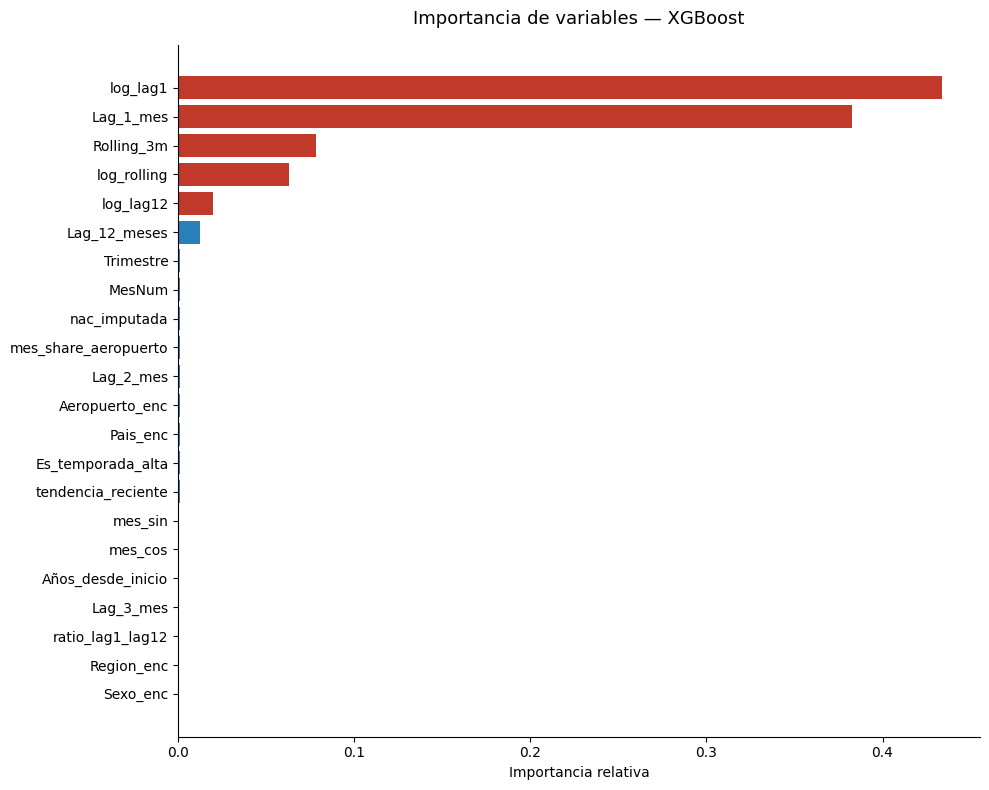

Ranking:
  log_lag1                43.4%  ##################################################################################################################################
  Lag_1_mes               38.3%  ##################################################################################################################
  Rolling_3m               7.8%  #######################
  log_rolling              6.3%  ##################
  log_lag12                2.0%  #####
  Lag_12_meses             1.2%  ###
  Trimestre                0.1%  #
  MesNum                   0.1%  #
  nac_imputada             0.1%  #
  mes_share_aeropuerto     0.1%  #
  Lag_2_mes                0.1%  #
  Aeropuerto_enc           0.1%  #
  Pais_enc                 0.1%  #
  Es_temporada_alta        0.1%  #
  tendencia_reciente       0.1%  #
  mes_sin                  0.1%  #
  mes_cos                  0.1%  #
  Años_desde_inicio        0.1%  #
  Lag_3_mes                0.1%  #
  ratio_lag1_lag12         0.1%  #
  Re

In [8]:
importancias = pd.Series(
    xgb_final.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colores = ['#c0392b' if i < 5 else '#2980b9' for i in range(len(importancias))]
ax.barh(importancias.index[::-1], importancias.values[::-1],
        color=colores[::-1], edgecolor='none')
ax.set_title('Importancia de variables — XGBoost', fontsize=13, pad=15)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print("Ranking:")
for feat, imp in importancias.items():
    barra = '#' * max(1, int(imp * 300))
    print(f"  {feat:<22} {imp*100:5.1f}%  {barra}")

# Diagnostico de concentracion
top2 = importancias.head(2).sum()
if top2 > 0.80:
    print(f"\nAVISO: top 2 features concentran {top2*100:.1f}% — modelo posiblemente subentrenado.")
else:
    print(f"\nTop 2 features: {top2*100:.1f}% — distribucion aceptable.")

## 9. Diagnostico visual

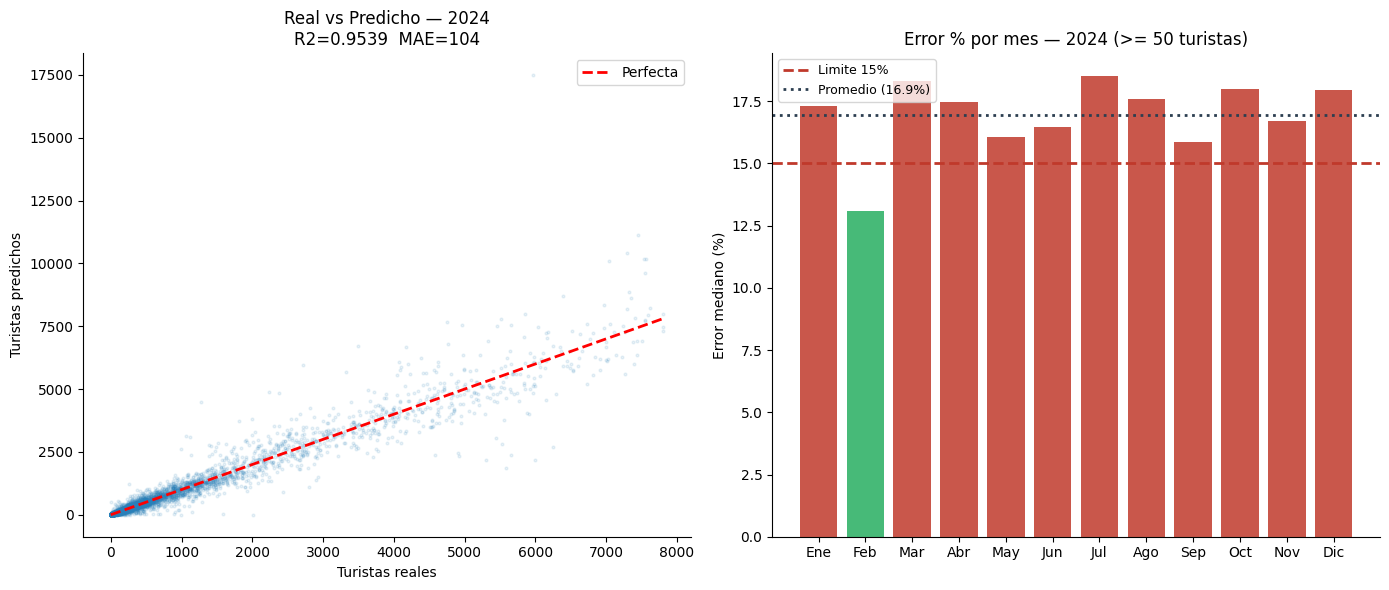

Meses sobre 15% en 2024: ['Ene', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

y24 = val24[TARGET].values
p99  = np.percentile(y24, 99)
mask_99 = y24 <= p99
axes[0].scatter(y24[mask_99], pred24[mask_99],
                alpha=0.1, s=4, color='#2980b9', rasterized=True)
axes[0].plot([0, p99], [0, p99], 'r--', lw=2, label='Perfecta')
axes[0].set_xlabel('Turistas reales')
axes[0].set_ylabel('Turistas predichos')
axes[0].set_title(f'Real vs Predicho — 2024\nR2={m24["r2"]}  MAE={m24["mae"]:,.0f}')
axes[0].legend()

v24 = val24.copy()
v24['pred']    = pred24
v24['err_pct'] = abs(v24[TARGET] - v24['pred']) / v24[TARGET].clip(lower=1) * 100
err_mes = v24[v24[TARGET] >= UMBRAL].groupby('MesNum')['err_pct'].median()

colores_mes = ['#c0392b' if v > 15 else '#27ae60' for v in err_mes.values]
axes[1].bar(meses_lbl, err_mes.values, color=colores_mes, alpha=0.85, edgecolor='none')
axes[1].axhline(y=15, color='#c0392b', ls='--', lw=2, label='Limite 15%')
axes[1].axhline(y=err_mes.mean(), color='#2c3e50', ls=':', lw=2,
                label=f'Promedio ({err_mes.mean():.1f}%)')
axes[1].set_title(f'Error % por mes — 2024 (>= {UMBRAL} turistas)')
axes[1].set_ylabel('Error mediano (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

meses_sobre = [meses_lbl[i-1] for i, v in err_mes.items() if v > 15]
print(f"Meses sobre 15% en 2024: {meses_sobre}")

## 10. Demo — Cancun · EE.UU. · Mujeres

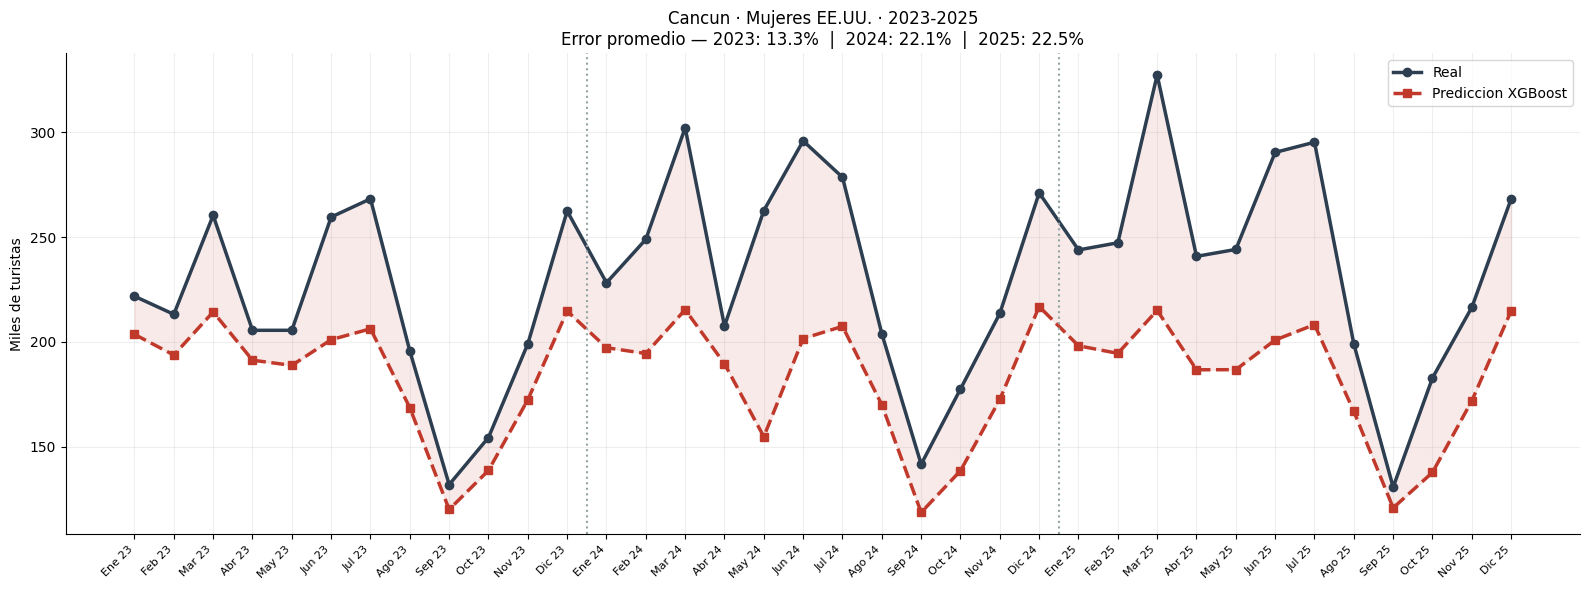

Error por anio:
  2023: 13.3%
  2024: 22.1%
  2025: 22.5%

Detalle mes a mes:
   Mes  Valor_Residencia    Prediccion  Error_pct
Ene 23            221806 203615.046875        8.2
Feb 23            213190 193765.093750        9.1
Mar 23            260371 214319.437500       17.7
Abr 23            205558 191306.484375        6.9
May 23            205572 188829.734375        8.1
Jun 23            259565 201083.046875       22.5
Jul 23            268271 206285.343750       23.1
Ago 23            195684 168642.531250       13.8
Sep 23            131970 120108.648438        9.0
Oct 23            154433 138745.468750       10.2
Nov 23            199131 172431.671875       13.4
Dic 23            262450 214715.093750       18.2
Ene 24            228242 197271.218750       13.6
Feb 24            248937 194482.109375       21.9
Mar 24            302152 215396.625000       28.7
Abr 24            207580 189625.031250        8.6
May 24            262677 154824.390625       41.1
Jun 24            2958

In [10]:
val_todo  = pd.concat([val23, val24, val25]).copy()
pred_todo = np.concatenate([pred23, pred24, pred25])
pred_s    = pd.Series(pred_todo, index=val_todo.index)
val_todo['Prediccion'] = pred_s
val_todo['Error_pct']  = (abs(val_todo[TARGET] - val_todo['Prediccion']) /
                          val_todo[TARGET] * 100).round(1)
val_todo['Mes'] = (val_todo['MesNum'].map(dict(enumerate(meses_lbl,1))) +
                   ' ' + val_todo['Ano'].astype(str).str[-2:])

cancun = val_todo[
    (val_todo['Aeropuerto'] == 'cancun, q. roo') &
    (val_todo['Pais'] == 'estados unidos') &
    (val_todo['Sexo'] == 'mujer')
].copy().sort_values(['Ano','MesNum'])

err_anio = cancun.groupby('Ano')['Error_pct'].mean()

fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(cancun))
ax.plot(x, cancun[TARGET]/1000,       'o-',  color='#2c3e50', lw=2.5, label='Real', ms=6)
ax.plot(x, cancun['Prediccion']/1000, 's--', color='#c0392b', lw=2.5,
        label='Prediccion XGBoost', ms=6)
ax.fill_between(x, cancun[TARGET]/1000, cancun['Prediccion']/1000,
                alpha=0.1, color='#c0392b')
for corte_x in [12, 24]:
    ax.axvline(x=corte_x-0.5, color='#95a5a6', ls=':', lw=1.5)
ax.set_xticks(x)
ax.set_xticklabels(cancun['Mes'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Miles de turistas')
err_str = '  |  '.join([f"{a}: {v:.1f}%" for a, v in err_anio.items()])
ax.set_title(f'Cancun · Mujeres EE.UU. · 2023-2025\nError promedio — {err_str}', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Error por anio:")
for a, v in err_anio.items():
    print(f"  {a}: {v:.1f}%")
print(f"\nDetalle mes a mes:")
print(cancun[['Mes', TARGET, 'Prediccion', 'Error_pct']].to_string(index=False))

## 11. Tabla comparativa final

In [11]:
# Metricas del Random Forest (del notebook 06)
RF = {
    '2023': {'r2': 0.9686, 'mae': 93.8,  'mape_g': 37.6, 'mape_n': 19.0},
    '2024': {'r2': 0.9833, 'mae': 77.3,  'mape_g': 37.8, 'mape_n': 19.0},
    '2025': {'r2': 0.9824, 'mae': 78.1,  'mape_g': 37.2, 'mape_n': 17.6},
}

print("=" * 80)
print("TABLA COMPARATIVA FINAL — XGBoost vs Random Forest")
print(f"Estandar industrial: MAPE negocio < 15%")
print("=" * 80)
print(f"{'Anio':<18} {'XGB R2':>8} {'XGB MAE':>10} {'XGB MAPE neg':>13} {'RF R2':>8} {'RF MAE':>10} {'RF MAPE neg':>12} {'Ganador':>9}")
print('-' * 80)

for anio_key, anio_label, m_xgb in [
    ('2023', '2023 (1 anio)', m23),
    ('2024', '2024 (2 anios)', m24),
    ('2025', '2025 (3 anios)', m25),
]:
    rf = RF[anio_key]
    ganador = 'XGBoost' if m_xgb['mape_n'] < rf['mape_n'] else 'RF'
    if abs(m_xgb['mape_n'] - rf['mape_n']) < 0.5:
        ganador = 'Empate'
    print(f"{anio_label:<18} {m_xgb['r2']:>8} {m_xgb['mae']:>10,.1f} {m_xgb['mape_n']:>12.1f}%"
          f" {rf['r2']:>8} {rf['mae']:>10,.1f} {rf['mape_n']:>11.1f}% {ganador:>9}")

print('=' * 80)
print(f"\nXGBoost — parametros:")
print(f"  Arboles:          {BEST_N}")
print(f"  learning_rate:    0.01")
print(f"  max_depth:        8")
print(f"  Early stopping:   sobre Jul-Dic 2022")
print(f"  Tiempo fase 2:    {TIEMPO}s")
print(f"  Device:           {DEVICE.upper()}")

TABLA COMPARATIVA FINAL — XGBoost vs Random Forest
Estandar industrial: MAPE negocio < 15%
Anio                 XGB R2    XGB MAE  XGB MAPE neg    RF R2     RF MAE  RF MAPE neg   Ganador
--------------------------------------------------------------------------------
2023 (1 anio)        0.9791       80.1         15.1%   0.9686       93.8        19.0%   XGBoost
2024 (2 anios)       0.9539      103.5         17.0%   0.9833       77.3        19.0%   XGBoost
2025 (3 anios)       0.9515      109.1         17.1%   0.9824       78.1        17.6%   XGBoost

XGBoost — parametros:
  Arboles:          1470
  learning_rate:    0.01
  max_depth:        8
  Early stopping:   sobre Jul-Dic 2022
  Tiempo fase 2:    8.2s
  Device:           CUDA
